In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker


In [2]:
fake=Faker()
Faker.seed(42)
np.random.seed(42)

In [3]:
#create a dataset for 100 students
student_count=100
school_name='Laposh high school'

In [4]:
#  Data Generation Logic 
def calculate_final_grade(hours, attendance):
    
    # Mathematical Modeling: Linear combination with stochastic noise
    base_score = 45 + (hours * 1.5) + (attendance / 10)
    noise = np.random.normal(0, 3) 
    final_score = base_score + noise
    return max(0, min(100, round(final_score, 2)))

raw_data = {
    'Student_ID': [f"STU_{i:03d}" for i in range(student_count)],
    'Name': [fake.name() for _ in range(student_count)],
    'Study_Hours': np.random.normal(15, 5, student_count).clip(0, 40),
    'Attendance_Rate': np.random.uniform(70, 100, student_count),
    'Exam_Score' : []
}

for i in range (student_count):
 score= calculate_final_grade(raw_data['Study_Hours'][i],raw_data['Attendance_Rate'][i])
 raw_data['Exam_Score'].append(score)
    
df = pd.DataFrame(raw_data)
df.head()


,Student_ID,Name,Study_Hours,Attendance_Rate,Exam_Score
0,STU_000,Allison Hill,17.483571,82.522330,79.52
1,STU_001,Noah Rhodes,14.308678,76.663234,78.49
2,STU_002,Angie Henderson,18.238443,73.595961,78.92
3,STU_003,Daniel Wagner,22.615149,80.128455,95.10
4,STU_004,Cristian Santos,13.829233,98.287291,77.45


In [5]:
mean_score= df['Exam_Score'].mean()
std_score= df['Exam_Score'].std()
df['Z_score']= (df['Exam_Score']- mean_score)/std_score
correlation=df['Exam_Score'].corr(df['Exam_Score'])
df.head()

,Student_ID,Name,Study_Hours,Attendance_Rate,Exam_Score,Z_score
0,STU_000,Allison Hill,17.483571,82.522330,79.52,0.550660
1,STU_001,Noah Rhodes,14.308678,76.663234,78.49,0.416549
2,STU_002,Angie Henderson,18.238443,73.595961,78.92,0.472537
3,STU_003,Daniel Wagner,22.615149,80.128455,95.10,2.579241
4,STU_004,Cristian Santos,13.829233,98.287291,77.45,0.281137


Text(0.5, 1.0, 'Impact of Study Hours (Corr: 1.00)')

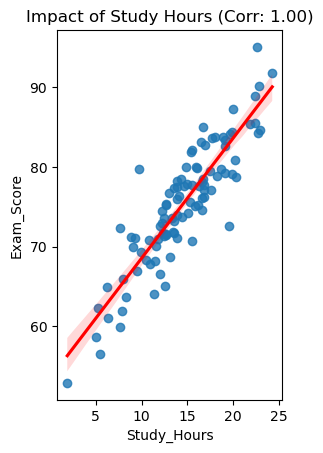

In [6]:
plt.subplot(1, 2, 1)
sns.regplot(x='Study_Hours', y='Exam_Score', data=df, line_kws={"color": "red"})
plt.title(f'Impact of Study Hours (Corr: {correlation:.2f})')